# Data Understanding & Exploratory Data Analysis  
## Détection des maladies mentales à partir de commentaires des réseaux sociaux

**Objectif du notebook** : comprendre précisément l'état du dataset avant le nettoyage et la modélisation.

Ce notebook répond aux questions principales :

- Quelles sont les classes présentes ?
- Combien de classes existe-t-il ?
- Le dataset est-il équilibré ?
- Quelle est la longueur moyenne des textes ?
- Les textes sont-ils courts ou longs ?
- Existe-t-il des textes vides ou manquants ?
- Y a-t-il des URLs, mentions, hashtags, emojis ?
- Les stopwords sont-ils fréquents ?
- Existe-t-il du slang / langage informel ?
- Y a-t-il des répétitions ou doublons ?
- Certaines classes semblent-elles confondues ?
- Quelles visualisations faut-il utiliser avant le nettoyage ?

## 0. Installation et importation des librairies

Cette cellule installe les librairies nécessaires si elles ne sont pas déjà disponibles.

In [9]:


import os
import re
import string
import warnings
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print("Librairies chargées avec succès.")

Librairies chargées avec succès.


## 1. Chargement du dataset

Le dataset utilisé   **mental-health-text-classification**.  
Le fichier attendu s'appelle généralement `data.csv` et contient deux colonnes principales :

- `statement` : le texte/commentaire.
- `status` : la classe de santé mentale.



In [10]:
import pandas as pd

df = pd.read_csv("data.csv")

print("Dimensions :", df.shape)
display(df.head())

Dimensions : (53043, 3)


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


## 2. Identification a des colonnes texte et label

On vérifie les colonnes disponibles, puis on détecte automatiquement :

- la colonne contenant les textes ;
- la colonne contenant les classes.

In [11]:
print("Colonnes disponibles :")
display(pd.DataFrame({
    "colonne": df.columns,
    "type": [df[col].dtype for col in df.columns],
    "valeurs_manquantes": [df[col].isna().sum() for col in df.columns],
    "nb_valeurs_uniques": [df[col].nunique(dropna=True) for col in df.columns]
}))

# Détection automatique des colonnes probables
text_candidates = ["statement", "text", "comment", "post", "content", "message"]
label_candidates = ["status", "label", "target", "class", "category", "diagnosis"]

TEXT_COL = None
LABEL_COL = None

for col in text_candidates:
    if col in df.columns:
        TEXT_COL = col
        break

for col in label_candidates:
    if col in df.columns:
        LABEL_COL = col
        break

if TEXT_COL is None:
    # fallback : colonne object avec les textes les plus longs en moyenne
    object_cols = df.select_dtypes(include=["object"]).columns
    TEXT_COL = max(object_cols, key=lambda c: df[c].astype(str).str.len().mean())

if LABEL_COL is None:
    # fallback : colonne avec peu de valeurs uniques
    possible_labels = [c for c in df.columns if c != TEXT_COL and df[c].nunique() <= 30]
    LABEL_COL = possible_labels[0] if possible_labels else None

print("Colonne texte détectée :", TEXT_COL)
print("Colonne label détectée :", LABEL_COL)

if LABEL_COL is None:
    raise ValueError("Impossible de détecter la colonne des classes. Vérifiez le nom de la colonne cible.")

Colonnes disponibles :


,colonne,type,valeurs_manquantes,nb_valeurs_uniques
0,Unnamed: 0,int64,0,53043
1,statement,object,362,51073
2,status,object,0,7


Colonne texte détectée : statement
Colonne label détectée : status


### Interprétation

À ce stade, on doit confirmer que le dataset possède bien :

- une colonne de texte exploitable ;
- une colonne cible contenant les classes à prédire.

Si la colonne détectée n'est pas correcte, il suffit de modifier manuellement :

```python
TEXT_COL = "nom_colonne_texte"
LABEL_COL = "nom_colonne_label"
```

## 3. Informations générales sur le dataset

Cette partie permet de comprendre la taille, les types des variables, les valeurs manquantes et les premières lignes du dataset.

In [12]:
print("Shape du dataset :", df.shape)
print("\nInformations générales :")
display(df.info())

print("\nAperçu des données :")
display(df[[TEXT_COL, LABEL_COL]].head(10))

print("\nValeurs manquantes par colonne :")
display(df.isna().sum().sort_values(ascending=False))

Shape du dataset : (53043, 3)

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


None


Aperçu des données :


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
5,"every break, you must be nervous, like somethi...",Anxiety
6,"I feel scared, anxious, what can I do? And may...",Anxiety
7,Have you ever felt nervous but didn't know why?,Anxiety
8,"I haven't slept well for 2 days, it's like I'm...",Anxiety
9,"I'm really worried, I want to cry.",Anxiety



Valeurs manquantes par colonne :


statement     362
Unnamed: 0      0
status          0
dtype: int64

## 4. Analyse des classes

Ici, on répond aux questions :

- Quelles sont les classes ?
- Combien de classes existe-t-il ?
- Combien d'exemples par classe ?

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

Nombre de classes : 7


,classe,nombre_exemples,pourcentage
0,Normal,16351,30.83
1,Depression,15404,29.04
2,Suicidal,10653,20.08
3,Anxiety,3888,7.33
4,Bipolar,2877,5.42
5,Stress,2669,5.03
6,Personality disorder,1201,2.26


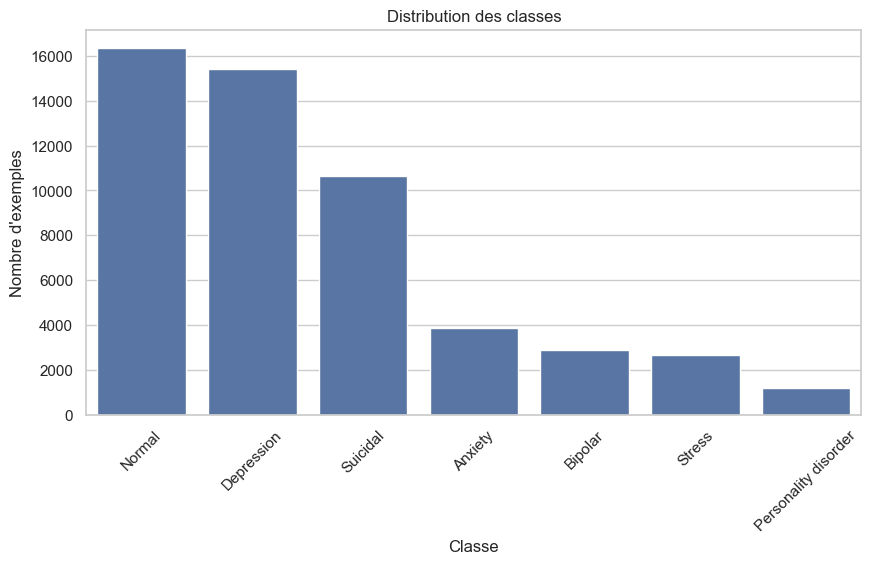

In [14]:
class_counts = df[LABEL_COL].value_counts(dropna=False)
class_percentages = df[LABEL_COL].value_counts(normalize=True, dropna=False) * 100

class_summary = pd.DataFrame({
    "classe": class_counts.index,
    "nombre_exemples": class_counts.values,
    "pourcentage": class_percentages.values.round(2)
})

print("Nombre de classes :", df[LABEL_COL].nunique(dropna=True))
display(class_summary)

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x=LABEL_COL, order=class_counts.index)
plt.title("Distribution des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'exemples")
plt.xticks(rotation=45)
plt.show()

### Interprétation de l'équilibre des classes

On calcule un ratio simple :

```text
ratio = taille_classe_majoritaire / taille_classe_minoritaire
```

- Ratio proche de 1 : dataset équilibré.
- Ratio entre 1.5 et 3 : déséquilibre modéré.
- Ratio supérieur à 3 : déséquilibre important.

In [15]:
valid_counts = df[LABEL_COL].value_counts()
majority = valid_counts.max()
minority = valid_counts.min()
imbalance_ratio = majority / minority

print("Classe majoritaire :", valid_counts.idxmax(), "->", majority, "exemples")
print("Classe minoritaire :", valid_counts.idxmin(), "->", minority, "exemples")
print("Ratio de déséquilibre :", round(imbalance_ratio, 2))

if imbalance_ratio < 1.5:
    print("\nInterprétation : le dataset semble globalement équilibré.")
elif imbalance_ratio < 3:
    print("\nInterprétation : le dataset présente un déséquilibre modéré. Il faudra surveiller le F1-score macro.")
else:
    print("\nInterprétation : le dataset est fortement déséquilibré. Il faudra utiliser class_weight, weighted loss ou des méthodes de rééquilibrage.")

Classe majoritaire : Normal -> 16351 exemples
Classe minoritaire : Personality disorder -> 1201 exemples
Ratio de déséquilibre : 13.61

Interprétation : le dataset est fortement déséquilibré. Il faudra utiliser class_weight, weighted loss ou des méthodes de rééquilibrage.


### Interprétation : le dataset est fortement déséquilibré. Il faudra utiliser class_weight, weighted loss ou des méthodes de rééquilibrage.

## 5. Analyse des textes manquants, vides ou invalides

On vérifie :

- valeurs `NaN`,
- textes vides,
- textes composés uniquement d'espaces,
- textes extrêmement courts.

In [16]:
df_eda = df.copy()

df_eda[TEXT_COL] = df_eda[TEXT_COL].astype(str)
df_eda["text_stripped"] = df_eda[TEXT_COL].str.strip()

df_eda["is_missing_text"] = df[TEXT_COL].isna()
df_eda["is_empty_text"] = df_eda["text_stripped"].eq("") | df_eda["text_stripped"].str.lower().isin(["nan", "none", "null"])
df_eda["char_count"] = df_eda["text_stripped"].str.len()
df_eda["word_count"] = df_eda["text_stripped"].apply(lambda x: len(x.split()))
df_eda["very_short_text"] = df_eda["word_count"] <= 3

quality_summary = pd.DataFrame({
    "problème": ["Textes manquants", "Textes vides", "Textes très courts <= 3 mots"],
    "nombre": [
        int(df_eda["is_missing_text"].sum()),
        int(df_eda["is_empty_text"].sum()),
        int(df_eda["very_short_text"].sum())
    ],
    "pourcentage": [
        round(df_eda["is_missing_text"].mean()*100, 2),
        round(df_eda["is_empty_text"].mean()*100, 2),
        round(df_eda["very_short_text"].mean()*100, 2)
    ]
})

display(quality_summary)

print("Exemples de textes très courts :")
display(df_eda.loc[df_eda["very_short_text"], [TEXT_COL, LABEL_COL, "word_count"]].head(10))

,problème,nombre,pourcentage
0,Textes manquants,362,0.68
1,Textes vides,362,0.68
2,Textes très courts <= 3 mots,2184,4.12


Exemples de textes très courts :


,statement,status,word_count
0,oh my gosh,Anxiety,3
32,Terooosss nervous huuuu,Anxiety,3
53,Restless.. and.. restless..,Anxiety,3
60,Very restless bgsd,Anxiety,3
67,nervous restless peramoy,Anxiety,3
70,It feels uneasy.,Anxiety,3
78,Restless and agitated.,Anxiety,3
88,Anxious,Anxiety,1
119,controlling excessive anxiety,Anxiety,3
150,Keep restless astagfirullah,Anxiety,3


### Interprétation

- Les textes vides doivent être supprimés avant la modélisation.
- Les textes très courts doivent être analysés avec prudence : ils peuvent être informatifs, mais aussi bruités.
- Pour un projet de santé mentale, un texte très court peut être ambigu et difficile à classer.

## 6. Analyse de la longueur des textes

On analyse :

- nombre de caractères ;
- nombre de mots ;
- distribution globale ;
- distribution par classe.

,count,mean,std,min,25%,50%,75%,max
char_count,53043.0,574.749185,844.686749,2.0,77.0,313.0,748.0,32759.0
word_count,53043.0,112.393285,163.436684,1.0,15.0,61.0,147.5,6300.0


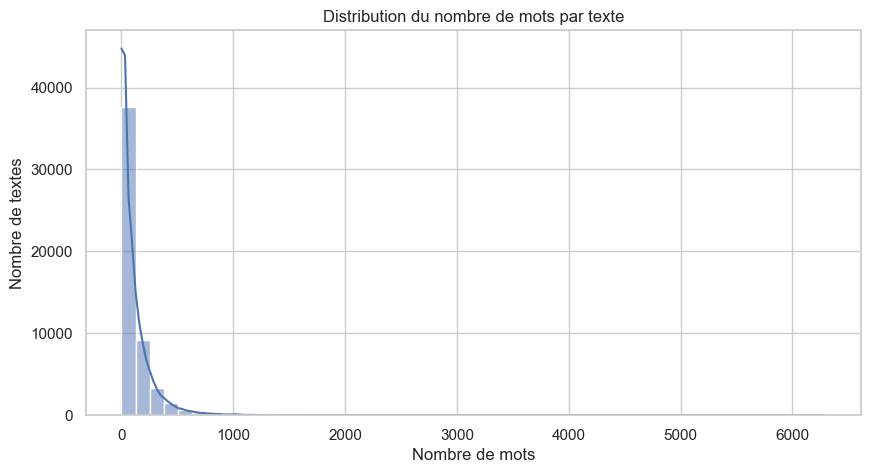

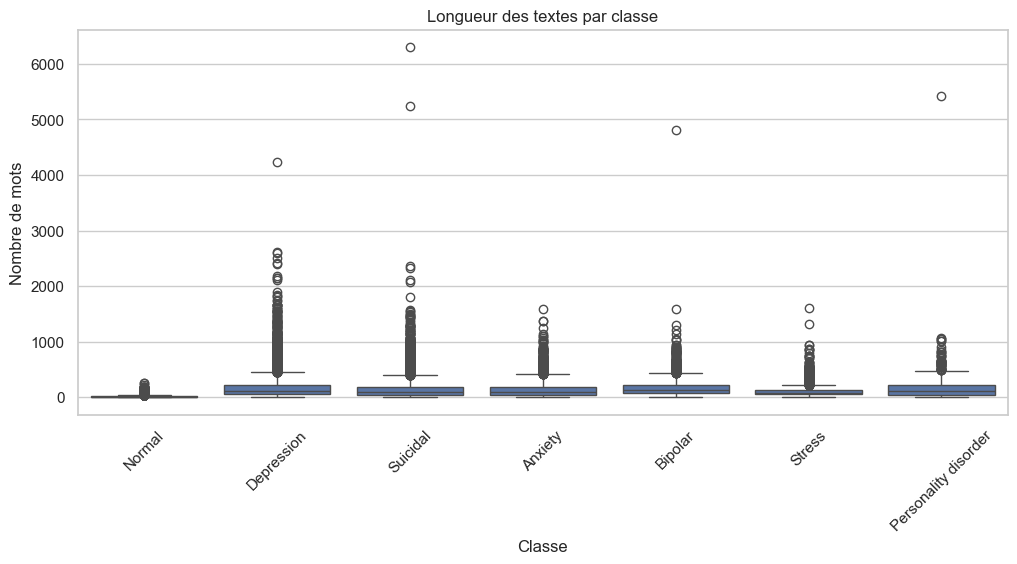

,count,mean,median,min,max
status,,,,,
Bipolar,2877,170.110532,125.0,1,4804
Depression,15404,168.021488,113.0,1,4239
Personality disorder,1201,160.932556,117.0,1,5419
Suicidal,10653,146.426640,92.0,1,6300
Anxiety,3888,142.110340,101.0,1,1592
Stress,2669,111.095541,85.0,1,1606
Normal,16351,17.238334,10.0,1,255


In [17]:
length_stats = df_eda[["char_count", "word_count"]].describe().T
display(length_stats)

plt.figure(figsize=(10, 5))
sns.histplot(df_eda["word_count"], bins=50, kde=True)
plt.title("Distribution du nombre de mots par texte")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de textes")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_eda, x=LABEL_COL, y="word_count", order=class_counts.index)
plt.title("Longueur des textes par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre de mots")
plt.xticks(rotation=45)
plt.show()

length_by_class = df_eda.groupby(LABEL_COL)["word_count"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("mean", ascending=False)

display(length_by_class)

### Interprétation  des longueurs

In [18]:
avg_words = df_eda["word_count"].mean()
median_words = df_eda["word_count"].median()

print("Longueur moyenne :", round(avg_words, 2), "mots")
print("Longueur médiane :", round(median_words, 2), "mots")

if median_words < 10:
    print("\nInterprétation : les textes sont majoritairement courts. TF-IDF avec n-grams peut être très utile.")
elif median_words < 40:
    print("\nInterprétation : les textes ont une longueur moyenne raisonnable. TF-IDF, SVM et Logistic Regression peuvent bien fonctionner.")
else:
    print("\nInterprétation : les textes sont relativement longs. Des méthodes comme embeddings ou transformers peuvent capturer davantage le contexte.")

Longueur moyenne : 112.39 mots
Longueur médiane : 61.0 mots

Interprétation : les textes sont relativement longs. Des méthodes comme embeddings ou transformers peuvent capturer davantage le contexte.


## 7. Analyse des URLs, mentions, hashtags et ponctuation

Les textes de réseaux sociaux contiennent souvent :

- URLs ;
- mentions `@user` ;
- hashtags ;
- ponctuation expressive ;
- points d'exclamation ou d'interrogation répétés.

Ces éléments peuvent influencer le nettoyage.

,feature,total,textes_concernés,pourcentage_textes
0,num_urls,873,764,1.44
1,num_mentions,1094,925,1.74
2,num_hashtags,1754,851,1.60
3,num_exclamation,7263,3748,7.07
4,num_question,30999,15977,30.12
5,num_uppercase_words,33504,9976,18.81


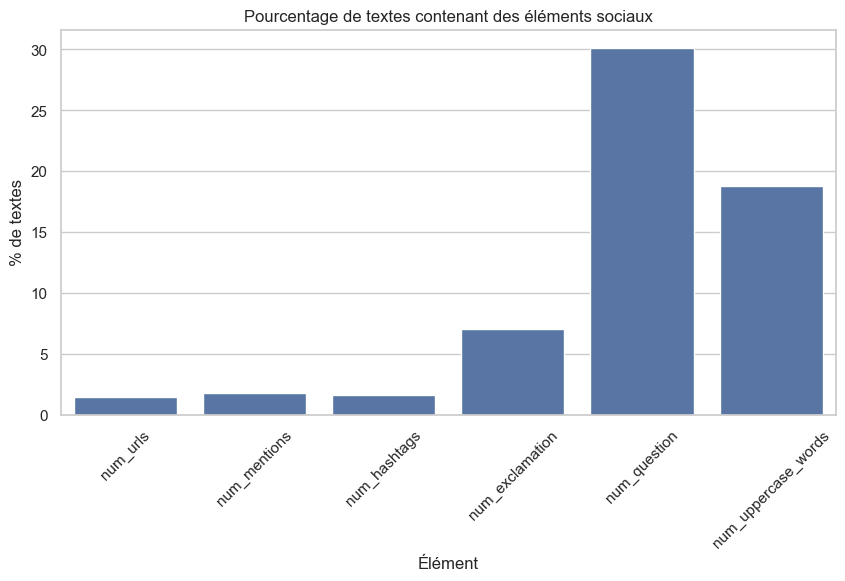

In [19]:
url_pattern = r"http[s]?://\S+|www\.\S+"
mention_pattern = r"@\w+"
hashtag_pattern = r"#\w+"

df_eda["num_urls"] = df_eda["text_stripped"].str.count(url_pattern)
df_eda["num_mentions"] = df_eda["text_stripped"].str.count(mention_pattern)
df_eda["num_hashtags"] = df_eda["text_stripped"].str.count(hashtag_pattern)
df_eda["num_exclamation"] = df_eda["text_stripped"].str.count(r"!")
df_eda["num_question"] = df_eda["text_stripped"].str.count(r"\?")
df_eda["num_uppercase_words"] = df_eda["text_stripped"].apply(
    lambda x: sum(1 for w in x.split() if len(w) > 1 and w.isupper())
)

social_features = ["num_urls", "num_mentions", "num_hashtags", "num_exclamation", "num_question", "num_uppercase_words"]

social_summary = pd.DataFrame({
    "feature": social_features,
    "total": [int(df_eda[col].sum()) for col in social_features],
    "textes_concernés": [int((df_eda[col] > 0).sum()) for col in social_features],
    "pourcentage_textes": [round((df_eda[col] > 0).mean()*100, 2) for col in social_features]
})

display(social_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=social_summary, x="feature", y="pourcentage_textes")
plt.title("Pourcentage de textes contenant des éléments sociaux")
plt.xlabel("Élément")
plt.ylabel("% de textes")
plt.xticks(rotation=45)
plt.show()

### Interprétation

- Les URLs sont généralement supprimées car elles ajoutent peu de contenu sémantique.
- Les mentions peuvent être supprimées pour éviter un bruit lié aux utilisateurs.
- Les hashtags peuvent être utiles s'ils contiennent des mots importants.
- La ponctuation expressive peut refléter une intensité émotionnelle.

## 8. Analyse des emojis

Les emojis peuvent porter une information émotionnelle importante dans un contexte de santé mentale.

Exemples :

- 😢 peut indiquer tristesse ;
- 😭 peut indiquer détresse ;
- ❤️ peut indiquer soutien ;
- 😡 peut indiquer colère.

Il ne faut donc pas les supprimer automatiquement sans analyse.

Nombre total d'emojis : 521
Pourcentage de textes avec emojis : 0.62 %


,emoji,frequence
0,😭,50
1,❤,42
2,😔,29
3,😂,19
4,🏴,14
5,🥲,14
6,🤦,13
7,😅,12
8,✨,12
9,🏻,11


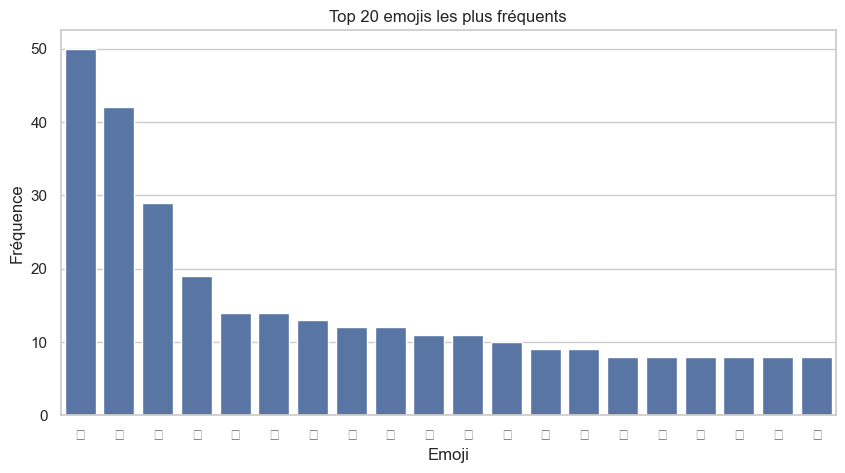

Exemples de textes avec emojis :


,statement,status,emojis
1277,"There are people who died, their friends didn'...",Normal,[❤]
1687,Seeing the sunny weather this morning after it...,Normal,[❤]
2046,"If I go out, I don't see the phone, so I have ...",Normal,[❤]
2343,emotion? ?! emotion. . emotion ?? HARU â™¡ ......,Normal,[❤]
2944,"""I have tf ya"" is a love language. ❤",Normal,[❤]
3281,"The flash is 5 minutes, remind me hmmmmm. ❤",Normal,[❤]
4245,"Bismillah, it's good to be Dobby. You can, zan...",Normal,[❤]
4747,"Faheema is now sleeping, he's always awake whe...",Normal,[❤]
5168,June????? NEXT MONTH? ❤,Normal,[❤]
5365,The spirit of Monday. It doesn't feel like Eid...,Normal,[❤]


In [20]:
import re
from collections import Counter

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA70-\U0001FAFF"
    "]+",
    flags=re.UNICODE
)

def extract_emojis(text):
    return emoji_pattern.findall(text)

df_eda["emojis"] = df_eda["text_stripped"].apply(extract_emojis)
df_eda["num_emojis"] = df_eda["emojis"].apply(lambda x: sum(len(e) for e in x))

print("Nombre total d'emojis :", int(df_eda["num_emojis"].sum()))
print("Pourcentage de textes avec emojis :", round((df_eda["num_emojis"] > 0).mean()*100, 2), "%")

all_emojis = []
for emojis in df_eda["emojis"]:
    for group in emojis:
        all_emojis.extend(list(group))

emoji_counts = Counter(all_emojis)
emoji_df = pd.DataFrame(emoji_counts.most_common(20), columns=["emoji", "frequence"])

display(emoji_df)

if len(emoji_df) > 0:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=emoji_df, x="emoji", y="frequence")
    plt.title("Top 20 emojis les plus fréquents")
    plt.xlabel("Emoji")
    plt.ylabel("Fréquence")
    plt.show()

print("Exemples de textes avec emojis :")
display(df_eda.loc[df_eda["num_emojis"] > 0, [TEXT_COL, LABEL_COL, "emojis"]].head(10))

### Interprétation

Si les emojis sont fréquents, il est préférable de les transformer en mots plutôt que de les supprimer.  
Exemple : 😢 → `sad emoji`.

Cela permet de conserver l'information émotionnelle.

## 9. Analyse des stopwords

Les stopwords sont des mots très fréquents comme :

- `the`, `and`, `is`, `to`, etc.

Mais attention : en santé mentale, certains mots courts sont importants.

Exemples :

- `not happy`
- `not okay`
- `never fine`

Donc on doit éviter de supprimer naïvement les négations comme `not`, `no`, `never`.

Ratio moyen de stopwords : 0.506


,stopword,frequence
0,i,421681
1,to,197884
2,and,176352
3,the,127413
4,my,120189
5,a,118032
6,it,90813
7,of,85012
8,not,76544
9,me,73207


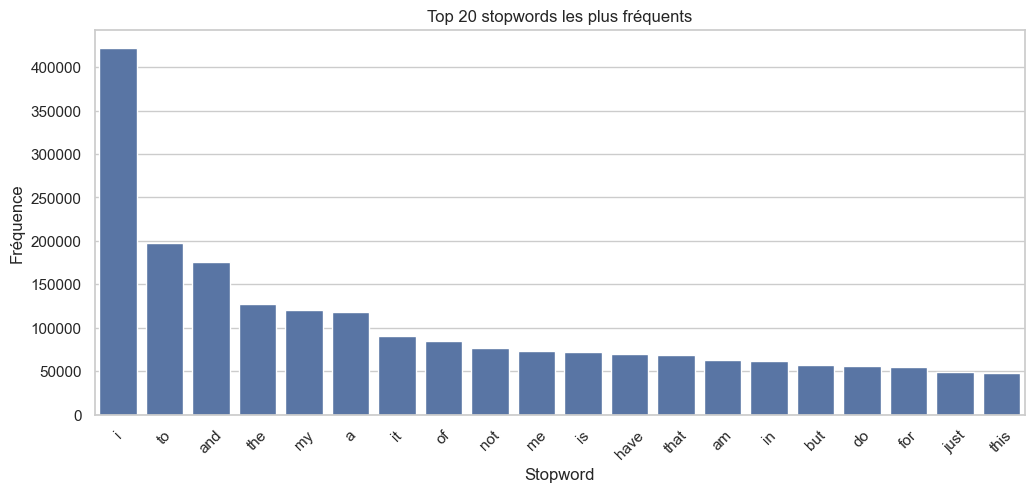

Fréquence des négations importantes :


,negation,frequence
0,not,76544
1,no,18975
2,never,11799
4,none,757
3,nor,483
5,n't,2


In [21]:
try:
    import nltk
    from nltk.corpus import stopwords
    nltk.download("stopwords", quiet=True)
    stop_words = set(stopwords.words("english"))
except Exception:
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    stop_words = set(ENGLISH_STOP_WORDS)

important_negations = {"no", "not", "nor", "never", "none", "n't"}
safe_stop_words = stop_words - important_negations

def simple_tokenize(text):
    return re.findall(r"\b[a-zA-Z']+\b", text.lower())

df_eda["tokens"] = df_eda["text_stripped"].apply(simple_tokenize)
df_eda["num_tokens"] = df_eda["tokens"].apply(len)
df_eda["num_stopwords"] = df_eda["tokens"].apply(lambda toks: sum(1 for t in toks if t in stop_words))
df_eda["stopword_ratio"] = df_eda.apply(
    lambda row: row["num_stopwords"] / row["num_tokens"] if row["num_tokens"] > 0 else 0,
    axis=1
)

print("Ratio moyen de stopwords :", round(df_eda["stopword_ratio"].mean(), 3))

all_tokens = [tok for toks in df_eda["tokens"] for tok in toks]
stopword_counts = Counter([tok for tok in all_tokens if tok in stop_words])

stopword_df = pd.DataFrame(stopword_counts.most_common(30), columns=["stopword", "frequence"])
display(stopword_df)

plt.figure(figsize=(12, 5))
sns.barplot(data=stopword_df.head(20), x="stopword", y="frequence")
plt.title("Top 20 stopwords les plus fréquents")
plt.xlabel("Stopword")
plt.ylabel("Fréquence")
plt.xticks(rotation=45)
plt.show()

negation_counts = Counter([tok for tok in all_tokens if tok in important_negations])
print("Fréquence des négations importantes :")
display(pd.DataFrame(negation_counts.items(), columns=["negation", "frequence"]).sort_values("frequence", ascending=False))

### Interprétation

Pour ce projet, il est recommandé de :

- supprimer certains stopwords très génériques ;
- conserver les négations (`not`, `no`, `never`) ;
- tester avec et sans stopwords pour voir l'impact sur la performance.

## 10. Analyse du slang et langage informel

Les commentaires de réseaux sociaux contiennent parfois du langage informel :

- `idk` = I don't know
- `imo` = in my opinion
- `lol`
- `btw`
- `u` = you
- `ur` = your
- `wanna`, `gonna`, etc.

Ces mots peuvent influencer le nettoyage et la normalisation.

In [22]:
slang_dict = {
    "idk": "i do not know",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "lol": "laughing out loud",
    "lmao": "laughing",
    "btw": "by the way",
    "u": "you",
    "ur": "your",
    "r": "are",
    "wanna": "want to",
    "gonna": "going to",
    "gotta": "got to",
    "kinda": "kind of",
    "sorta": "sort of",
    "bc": "because",
    "bcz": "because",
    "pls": "please",
    "plz": "please",
    "omg": "oh my god",
    "tbh": "to be honest",
    "rn": "right now",
    "tho": "though"
}

slang_terms = set(slang_dict.keys())

df_eda["num_slang"] = df_eda["tokens"].apply(lambda toks: sum(1 for t in toks if t in slang_terms))
df_eda["has_slang"] = df_eda["num_slang"] > 0

print("Pourcentage de textes contenant du slang :", round(df_eda["has_slang"].mean()*100, 2), "%")

all_slang = [tok for toks in df_eda["tokens"] for tok in toks if tok in slang_terms]
slang_counts = Counter(all_slang)
slang_df = pd.DataFrame(slang_counts.most_common(), columns=["slang", "frequence"])

display(slang_df)

print("Exemples de textes avec slang :")
display(df_eda.loc[df_eda["has_slang"], [TEXT_COL, LABEL_COL, "num_slang"]].head(10))

Pourcentage de textes contenant du slang : 9.98 %


,slang,frequence
0,idk,1818
1,lol,839
2,bc,755
3,u,552
4,kinda,473
5,gonna,470
6,r,442
7,tho,429
8,wanna,377
9,rn,368


Exemples de textes avec slang :


,statement,status,num_slang
122,The peak period of my stress has passed and I ...,Anxiety,1
234,What do you do when you're anxious when you're...,Anxiety,1
299,"um! Pls, how do I feel afraid to go out of the...",Anxiety,1
305,hello? buddy it's been a long time since jbjb ...,Anxiety,1
366,I can't take any more pressure pls!,Anxiety,1
438,"Kinda not very excited. Restless, many thought...",Anxiety,1
500,pls I'm so restless I can't sleep,Anxiety,1
599,"btw nutmeg I always get dizzy when I wake up, ...",Anxiety,1
675,"Pls want to sleep from being restless, why are...",Anxiety,1
706,"I rn: .. sluggish, tired, lethargic, limp, res...",Anxiety,1


### Interprétation

Si le slang est fréquent, on peut créer une fonction de normalisation.  
Exemple :

```text
idk → i do not know
u → you
ur → your
```

Cela peut améliorer la qualité du texte avant vectorisation.

## 11. Analyse des répétitions et caractères allongés

Les utilisateurs répètent parfois des lettres pour exprimer une émotion :

- `soooo sad`
- `nooooo`
- `pleaseeee`

Cela peut être une information émotionnelle, mais aussi un bruit pour le modèle.

In [23]:
elongated_pattern = re.compile(r"\b\w*(\w)\1{2,}\w*\b", re.IGNORECASE)

def find_elongated_words(text):
    return elongated_pattern.findall(text)

def count_elongated_words(text):
    words = text.split()
    return sum(1 for w in words if re.search(r"(\w)\1{2,}", w, re.IGNORECASE))

df_eda["num_elongated_words"] = df_eda["text_stripped"].apply(count_elongated_words)
df_eda["has_elongated_words"] = df_eda["num_elongated_words"] > 0

print("Pourcentage de textes avec mots allongés :", round(df_eda["has_elongated_words"].mean()*100, 2), "%")

print("Exemples de textes avec répétitions de caractères :")
display(df_eda.loc[df_eda["has_elongated_words"], [TEXT_COL, LABEL_COL, "num_elongated_words"]].head(10))

Pourcentage de textes avec mots allongés : 3.92 %
Exemples de textes avec répétitions de caractères :


,statement,status,num_elongated_words
32,Terooosss nervous huuuu,Anxiety,2
65,"I don't like worrying, I don't like wehhh!",Anxiety,1
163,Finally restless again uhh mmhhh ahh,Anxiety,1
212,"oh my god why have you been a week, you're so ...",Anxiety,1
231,"I just want to pass, there are so many obstacl...",Anxiety,1
392,Why do thoughts in the future always make you ...,Anxiety,1
410,so it's like this.. the authors never wanted t...,Anxiety,1
502,a little worried but it's okayyy,Anxiety,1
516,"Once gassi like each other, it's okay. ANJEEEE...",Anxiety,1
571,Sometimes feel anxious because tomorrow. .Tire...,Anxiety,1


### Interprétation

Les caractères répétés peuvent être normalisés :

```text
soooo → soo ou so
nooooo → noo ou no
```

Mais il faut éviter de perdre totalement l'information émotionnelle.

## 12. Analyse des doublons

On vérifie deux types de doublons :

1. doublons exacts ;
2. doublons après normalisation simple.

In [24]:
df_eda["normalized_text"] = (
    df_eda["text_stripped"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"[^a-zA-Z0-9\s]", "", regex=True)
    .str.strip()
)

exact_duplicates = df_eda.duplicated(subset=[TEXT_COL]).sum()
normalized_duplicates = df_eda.duplicated(subset=["normalized_text"]).sum()

print("Doublons exacts :", int(exact_duplicates))
print("Doublons après normalisation simple :", int(normalized_duplicates))

duplicate_examples = df_eda[df_eda.duplicated(subset=["normalized_text"], keep=False)].sort_values("normalized_text")
display(duplicate_examples[[TEXT_COL, LABEL_COL, "normalized_text"]].head(20))

Doublons exacts : 1969
Doublons après normalisation simple : 2072


,statement,status,normalized_text
6710,'«ð š «ð ©ð ²ð «..â £ ® © ®ð ¡ð ð ²ð «ð ..ðŸ' ...,Normal,
5305,”ð ®ð ®ð £ð ˜¬ð ©ð ˜¯ð ˜ºð . ˜¢ð ±ð ®ð ®ð ®ð ®...,Normal,
5321,â€â•°â”€âž›âœŽï¹ .ð € ®ð ..â€â€â€,Normal,
52931,10 years of Celexa/Lexapro and thinking of mak...,Anxiety,10 years of celexalexapro and thinking of maki...
51945,10 years of Celexa/Lexapro and thinking of mak...,Anxiety,10 years of celexalexapro and thinking of maki...
48273,"2 week depression episode Hi Everyone,\n\nI wa...",Depression,2 week depression episode hi everyone i was di...
47298,"2 week depression episode Hi Everyone,\n\nI wa...",Depression,2 week depression episode hi everyone i was di...
48501,2023 sucks so much for me right now. My PC sud...,Stress,2023 sucks so much for me right now my pc sudd...
49381,2023 sucks so much for me right now. My PC sud...,Stress,2023 sucks so much for me right now my pc sudd...
52927,27 yo with severe anxiety living with parents ...,Anxiety,27 yo with severe anxiety living with parents ...


### Interprétation

Les doublons peuvent poser problème car :

- ils peuvent créer de l'overfitting ;
- ils peuvent apparaître à la fois dans train et test ;
- ils peuvent gonfler artificiellement les performances.

Il faut donc supprimer les doublons avant le split final.

## 13. Analyse des mots les plus fréquents par classe

Cette étape permet de voir le vocabulaire dominant de chaque classe et d'observer les patterns linguistiques.

In [25]:
import numpy as np

In [26]:
from sklearn.feature_extraction.text import CountVectorizer

def top_words_by_class(data, text_col, label_col, class_name, n=20):
    texts = data.loc[data[label_col] == class_name, text_col].dropna().astype(str)
    if len(texts) == 0:
        return pd.DataFrame(columns=["word", "frequency"])

    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words=list(safe_stop_words),
        max_features=5000,
        token_pattern=r"\b[a-zA-Z']{2,}\b"
    )
    X = vectorizer.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    words = vectorizer.get_feature_names_out()
    top_idx = freqs.argsort()[::-1][:n]

    return pd.DataFrame({
        "word": words[top_idx],
        "frequency": freqs[top_idx]
    })

classes = df_eda[LABEL_COL].dropna().unique()

for cls in classes:
    print(f"\nTop words pour la classe : {cls}")
    display(top_words_by_class(df_eda, TEXT_COL, LABEL_COL, cls, n=15))


Top words pour la classe : Anxiety


,word,frequency
0,anxiety,3836
1,like,3295
2,not,2680
3,feel,2286
4,get,1987
5,know,1853
6,time,1637
7,really,1604
8,back,1285
9,something,1269



Top words pour la classe : Normal


,word,frequency
0,not,1705
1,like,1274
2,want,1123
3,get,876
4,really,860
5,time,816
6,go,758
7,no,755
8,one,753
9,know,736



Top words pour la classe : Depression


...

,word,frequency
0,like,1731
1,stress,1592
2,not,1513
3,feel,1341
4,get,1212
5,time,1038
6,know,1024
7,even,806
8,work,802
9,really,773



Top words pour la classe : Bipolar


,word,frequency
0,like,3044
1,not,2551
2,feel,2393
3,bipolar,1883
4,get,1816
5,know,1787
6,time,1524
7,really,1495
8,want,1311
9,even,1107



Top words pour la classe : Personality disorder


,word,frequency
0,like,1686
1,people,1244
2,not,1194
3,feel,1102
4,even,795
5,know,790
6,get,639
7,want,627
8,avpd,619
9,life,607


## 14. WordCloud par classe

Le WordCloud permet de visualiser rapidement :

- le vocabulaire dominant ;
- les émotions fréquentes ;
- les patterns par classe.

In [27]:
df_eda = df.copy()

TEXT_COL = "statement"
LABEL_COL = "status"

classes = df_eda[LABEL_COL].dropna().unique()

In [28]:
classes = df_eda[LABEL_COL].dropna().unique()

In [29]:
!pip install wordcloud


In [30]:
from wordcloud import WordCloud

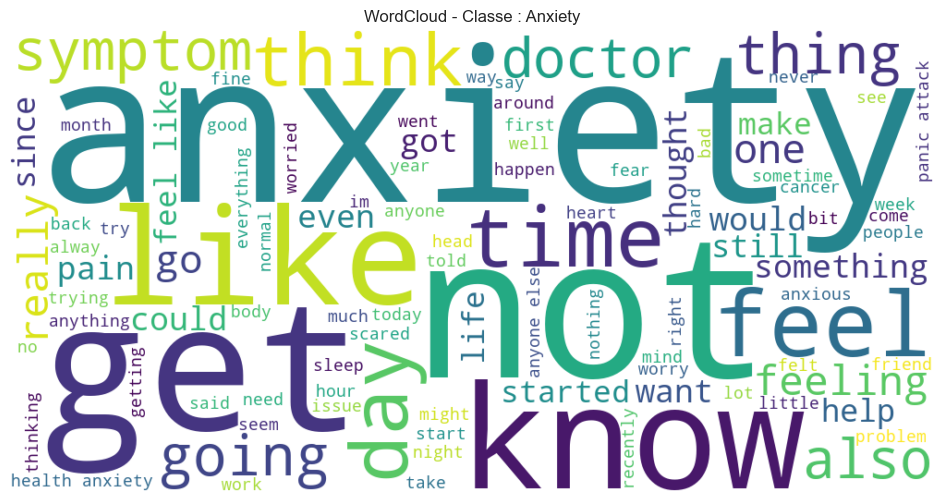

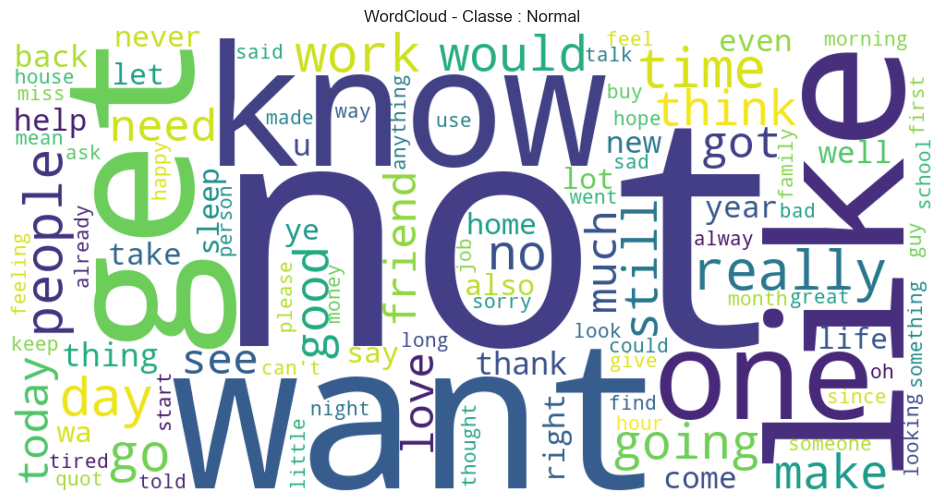

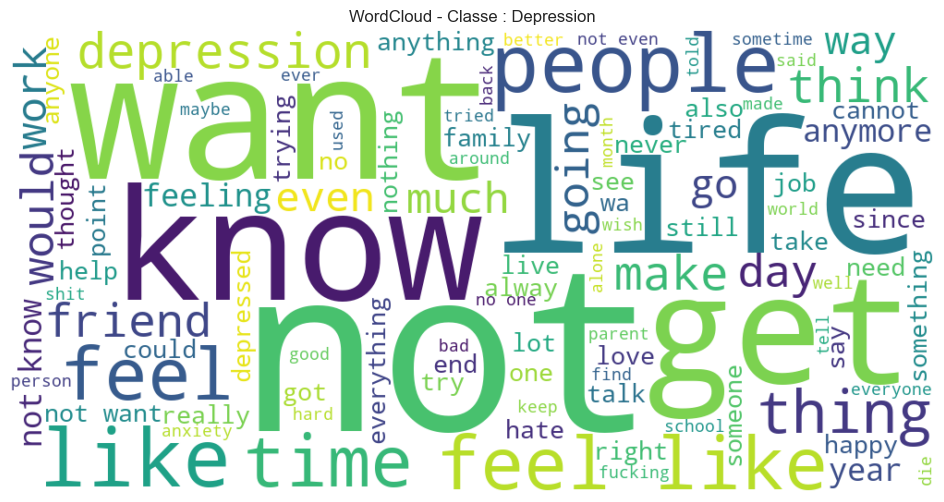

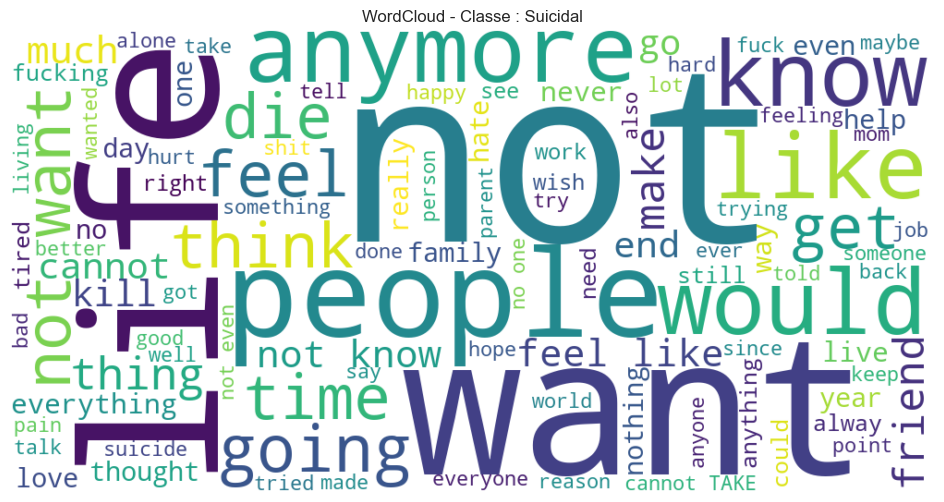

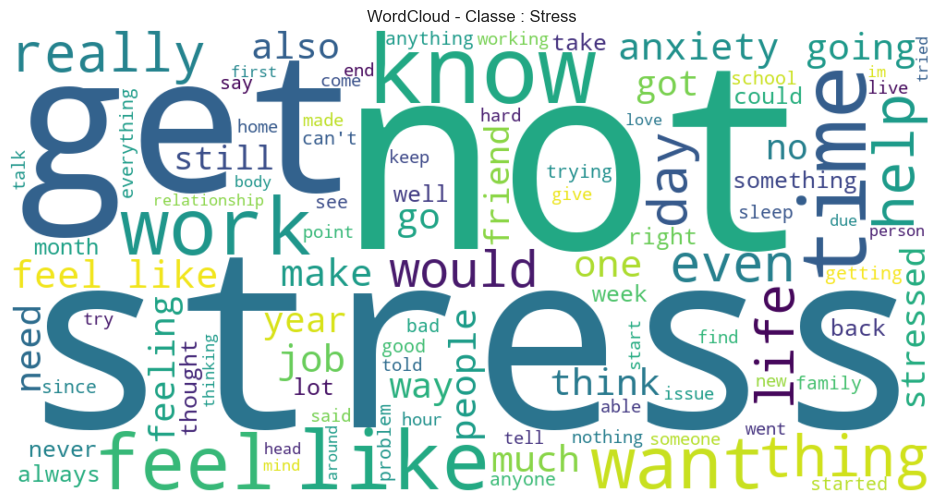

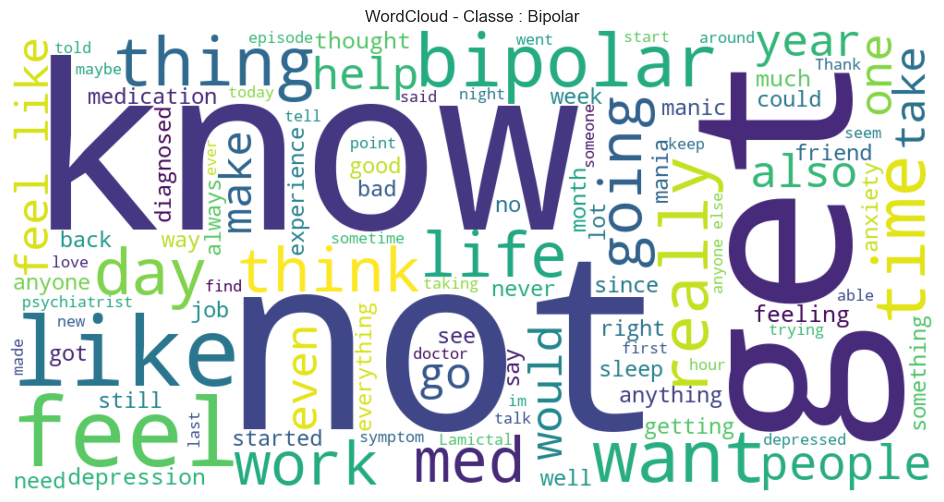

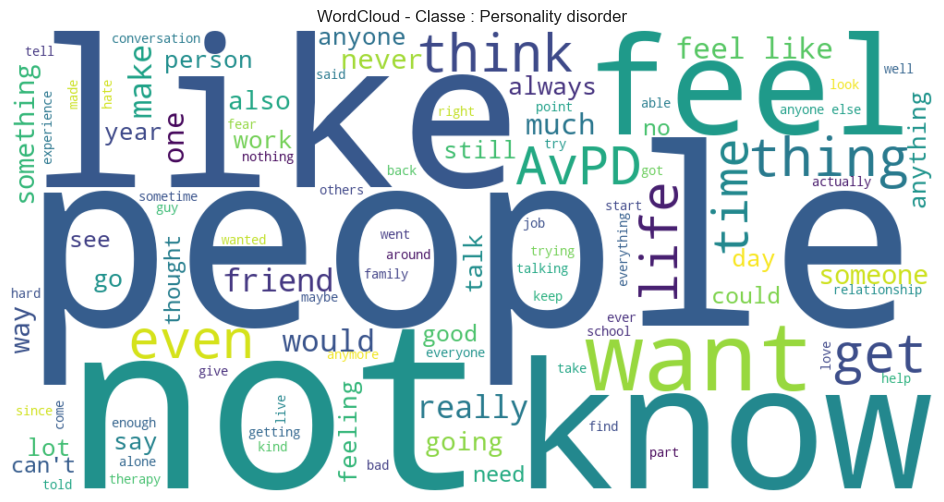

In [31]:
try:
    from wordcloud import WordCloud

    for cls in classes:
        class_text = " ".join(
            df_eda.loc[df_eda[LABEL_COL] == cls, TEXT_COL]
            .dropna()
            .astype(str)
            .tolist()
        )

        if len(class_text.strip()) == 0:
            continue

        wc = WordCloud(
            width=1000,
            height=500,
            background_color="white",
            stopwords=safe_stop_words,
            max_words=100
        ).generate(class_text)

        plt.figure(figsize=(12, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"WordCloud - Classe : {cls}")
        plt.show()

except Exception as e:
    print("Impossible de générer les WordClouds.")
    print("Installez la librairie avec : pip install wordcloud")
    print("Erreur :", e)

## 15. Analyse des classes potentiellement confondues

On cherche si certaines classes utilisent un vocabulaire très similaire.

Méthode simple :

- extraire les mots les plus fréquents par classe ;
- comparer les intersections de vocabulaire ;
- calculer un score de similarité de Jaccard.

Plus le score est élevé, plus deux classes partagent un vocabulaire proche.

,classe_1,classe_2,jaccard_similarity,mots_communs
11,Depression,Suicidal,0.754,"time, make, hard, people, thing, think, someon..."
14,Depression,Personality disorder,0.639,"time, make, hard, people, thing, think, lot, s..."
12,Depression,Stress,0.626,"time, make, hard, people, thing, think, lot, s..."
19,Stress,Personality disorder,0.613,"time, make, also, help, take, going, family, n..."
18,Stress,Bipolar,0.600,"time, make, also, months, take, help, going, n..."
4,Anxiety,Bipolar,0.575,"time, make, also, months, take, help, going, s..."
13,Depression,Bipolar,0.562,"time, make, also, help, take, going, no, start..."
20,Bipolar,Personality disorder,0.550,"time, make, also, help, take, going, sure, no,..."
17,Suicidal,Personality disorder,0.550,"time, make, also, help, take, going, family, n..."
3,Anxiety,Stress,0.538,"time, make, also, months, take, help, going, n..."


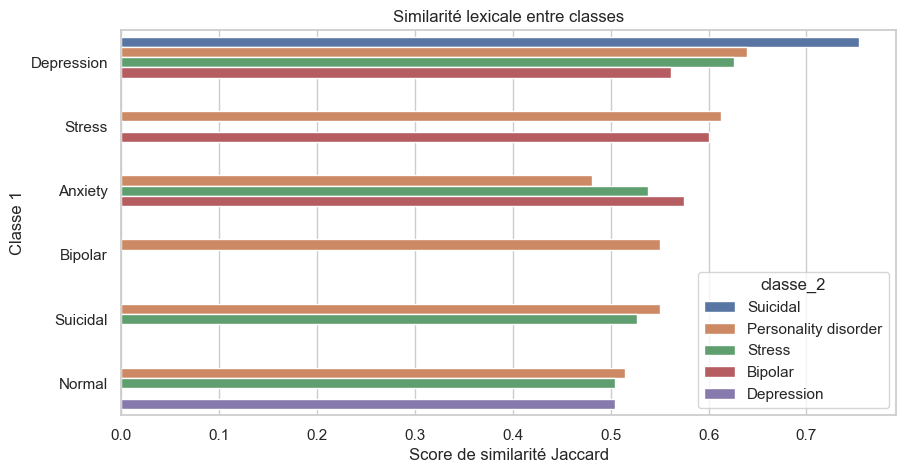

In [32]:
def top_word_set(data, text_col, label_col, class_name, n=100):
    top_df = top_words_by_class(data, text_col, label_col, class_name, n=n)
    return set(top_df["word"].tolist())

class_word_sets = {cls: top_word_set(df_eda, TEXT_COL, LABEL_COL, cls, n=100) for cls in classes}

similarities = []

for i, cls1 in enumerate(classes):
    for cls2 in classes[i+1:]:
        set1 = class_word_sets[cls1]
        set2 = class_word_sets[cls2]
        if len(set1.union(set2)) == 0:
            score = 0
        else:
            score = len(set1.intersection(set2)) / len(set1.union(set2))
        similarities.append({
            "classe_1": cls1,
            "classe_2": cls2,
            "jaccard_similarity": round(score, 3),
            "mots_communs": ", ".join(list(set1.intersection(set2))[:15])
        })

similarity_df = pd.DataFrame(similarities).sort_values("jaccard_similarity", ascending=False)
display(similarity_df)

if len(similarity_df) > 0:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=similarity_df.head(15), x="jaccard_similarity", y="classe_1", hue="classe_2")
    plt.title("Similarité lexicale entre classes")
    plt.xlabel("Score de similarité Jaccard")
    plt.ylabel("Classe 1")
    plt.show()

### Interprétation

Si deux classes ont une forte similarité lexicale, cela signifie qu'elles peuvent être plus difficiles à distinguer pour les modèles classiques.

Exemples possibles :

- Anxiety vs Stress ;
- Depression vs Suicidal ;
- Normal vs certains textes courts ambigus.

Dans la suite du projet, la matrice de confusion permettra de confirmer ces confusions.

## 16. Résumé automatique des observations principales

Cette cellule génère une synthèse utile à copier dans le rapport ou à utiliser pour préparer le nettoyage.

In [34]:
# =========================
# VARIABLES NÉCESSAIRES POUR LA SYNTHÈSE
# =========================

df_eda["text_stripped"] = df_eda[TEXT_COL].fillna("").astype(str).str.strip()

df_eda["is_empty_text"] = df_eda["text_stripped"].eq("")

df_eda["num_words"] = df_eda["text_stripped"].apply(lambda x: len(x.split()))

df_eda["very_short_text"] = df_eda["num_words"] <= 3

if "num_urls" not in df_eda.columns:
    df_eda["num_urls"] = df_eda["text_stripped"].str.count(r"http\S+|www\.\S+")

if "num_emojis" not in df_eda.columns:
    df_eda["num_emojis"] = 0

if "has_slang" not in df_eda.columns:
    df_eda["has_slang"] = False

valid_counts = df_eda[LABEL_COL].value_counts()
imbalance_ratio = valid_counts.max() / valid_counts.min()

avg_words = df_eda["num_words"].mean()
median_words = df_eda["num_words"].median()

exact_duplicates = df_eda.duplicated(subset=[TEXT_COL]).sum()

normalized_text = (
    df_eda["text_stripped"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

normalized_duplicates = normalized_text.duplicated().sum()

In [35]:
summary = []

summary.append(f"Le dataset contient {df_eda.shape[0]} lignes et {df_eda.shape[1]} colonnes après ajout des variables d'analyse.")
summary.append(f"La colonne texte détectée est '{TEXT_COL}' et la colonne cible est '{LABEL_COL}'.")
summary.append(f"Le nombre de classes est {df_eda[LABEL_COL].nunique(dropna=True)}.")
summary.append(f"La classe majoritaire est '{valid_counts.idxmax()}' avec {valid_counts.max()} exemples.")
summary.append(f"La classe minoritaire est '{valid_counts.idxmin()}' avec {valid_counts.min()} exemples.")
summary.append(f"Le ratio de déséquilibre est {round(imbalance_ratio, 2)}.")
summary.append(f"La longueur moyenne des textes est de {round(avg_words, 2)} mots, avec une médiane de {round(median_words, 2)} mots.")
summary.append(f"Le nombre de textes vides est {int(df_eda['is_empty_text'].sum())}.")
summary.append(f"Le pourcentage de textes très courts est {round(df_eda['very_short_text'].mean()*100, 2)}%.")
summary.append(f"Le pourcentage de textes contenant des URLs est {round((df_eda['num_urls'] > 0).mean()*100, 2)}%.")
summary.append(f"Le pourcentage de textes contenant des emojis est {round((df_eda['num_emojis'] > 0).mean()*100, 2)}%.")
summary.append(f"Le pourcentage de textes contenant du slang est {round(df_eda['has_slang'].mean()*100, 2)}%.")
summary.append(f"Le nombre de doublons exacts est {int(exact_duplicates)}.")
summary.append(f"Le nombre de doublons après normalisation simple est {int(normalized_duplicates)}.")

print("SYNTHÈSE DATA UNDERSTANDING")
print("="*50)
for item in summary:
    print("- " + item)

SYNTHÈSE DATA UNDERSTANDING
- Le dataset contient 53043 lignes et 10 colonnes après ajout des variables d'analyse.
- La colonne texte détectée est 'statement' et la colonne cible est 'status'.
- Le nombre de classes est 7.
- La classe majoritaire est 'Normal' avec 16351 exemples.
- La classe minoritaire est 'Personality disorder' avec 1201 exemples.
- Le ratio de déséquilibre est 13.61.
- La longueur moyenne des textes est de 112.39 mots, avec une médiane de 61.0 mots.
- Le nombre de textes vides est 362.
- Le pourcentage de textes très courts est 4.12%.
- Le pourcentage de textes contenant des URLs est 1.44%.
- Le pourcentage de textes contenant des emojis est 0.0%.
- Le pourcentage de textes contenant du slang est 0.0%.
- Le nombre de doublons exacts est 1969.
- Le nombre de doublons après normalisation simple est 1998.


## 17. Décisions recommandées pour passer au Data Cleaning

À partir de cette analyse, on prépare les décisions suivantes :

### À supprimer

- textes vides ;
- lignes sans label ;
- doublons exacts ou quasi identiques ;
- URLs si elles ne portent pas d'information utile ;
- mentions utilisateurs.

### À conserver ou transformer avec prudence

- emojis : à transformer en mots si fréquents ;
- négations : `not`, `no`, `never` doivent être conservées ;
- hashtags : à nettoyer mais parfois conserver le mot ;
- ponctuation émotionnelle : possibilité de créer des features ;
- mots allongés : normaliser sans perdre l'intensité émotionnelle.

### À surveiller

- classes déséquilibrées ;
- textes très courts ;
- classes lexicalement proches ;
- confusion possible entre certaines catégories.

### Prochaine étape

Construire un notebook de **Data Cleaning & Preprocessing** basé sur les résultats de cette exploration.